# Logistic Regression

Logistic regression is a fundamental statistical and machine learning algorithm used to predict the probability of a binary outcome (a yes/no, true/false, or 0/1 decision).

It is primarily used for classification rather than predicting continuous numbers (like housing prices). For instance, it’s commonly used to determine if an email is spam or not spam, or if a transaction is fraudulent or legitimate.

Logistic regression takes the linear equation and passes it through a special mathematical function called the Sigmoid (or Logistic) function.

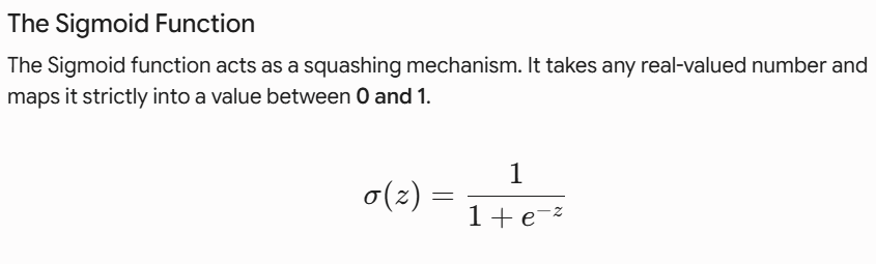
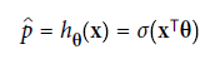

Decision Boundary:

Sigmoid function outputs a probability and applies a threshold—usually 0.5—to make a final classification:
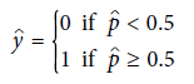

Logistic Regression Loss Function:
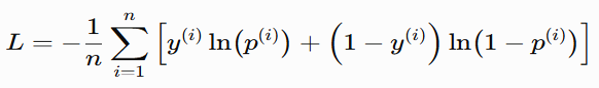

## linear function

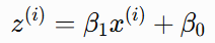

Substituting this in L and taking partial derivatives gives:

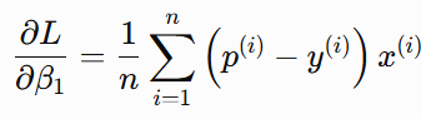 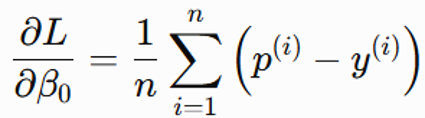

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

weight: 3.8565 bias: -14.1653
x_data:            [3.78 2.44 2.09 0.14 1.72 1.65 4.92 4.37 4.96 4.52 3.69 5.88]
Original_labels:   [0 0 0 0 0 0 1 1 1 1 1 1]
probablities:      [0.601636, 0.008532, 0.002226, 1e-06, 0.000535, 0.000409, 0.991907, 0.936292, 0.993056, 0.963247, 0.516294, 0.999799]
Model_predictions: [1 0 0 0 0 0 1 1 1 1 1 1]
0.6667


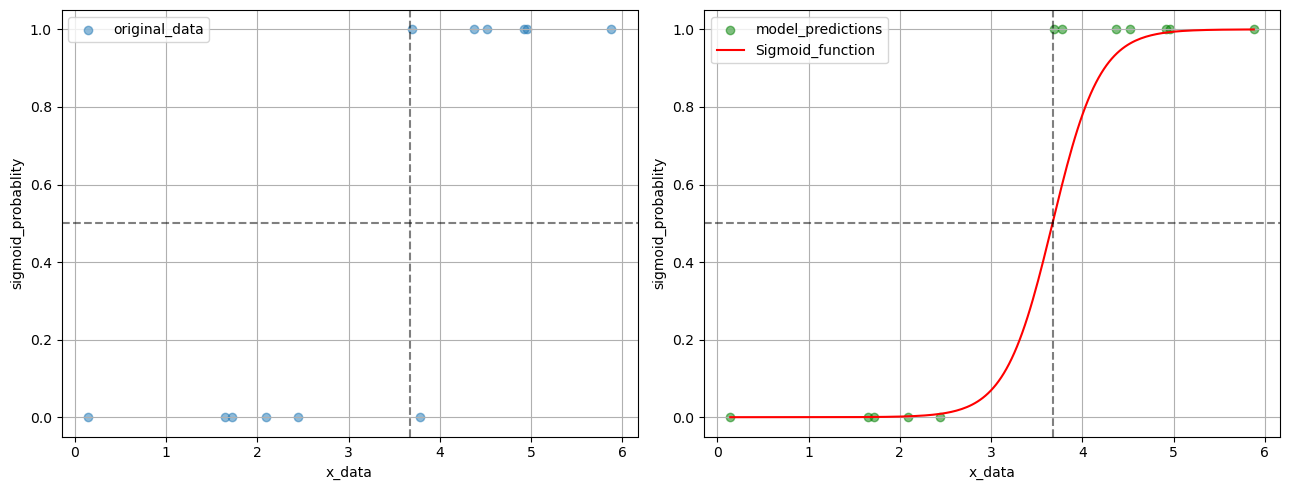

In [9]:
x = np.array([3.78, 2.44, 2.09, 0.14, 1.72, 1.65, 4.92, 4.37, 4.96, 4.52, 3.69, 5.88])
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
m = len(x)
def get_constants(x,y):
    a,b = 0.0,0.0
    itr_max = 50000
    lr = 0.05
    for i in range(itr_max):
        p = 1/(1+np.exp(-(a*x + b)))
        da = (1/m)*(np.dot((p-y), x))
        db = (1/m)*(np.sum(p-y))
        a = a - lr*da
        b = b - lr*db
    return a,b
def predict(a,b,x):
    x = np.array(x)
    prob = 1/(1+np.exp(-(a*x +b)))
    return (prob >=0.5).astype(int)
def prob(a,b,x):
    x = np.array(x)
    y = [float(round(ele,6)) for ele in 1/(1+np.exp(-(a*x +b)))]
    return y
a,b = get_constants(x,y)
print(f'weight: {a:.4f} bias: {b:.4f}')
print(f'x_data:           ',x)
print(f'Original_labels:  ',y)
print(f'probablities:     ',prob(a,b,x))
print(f'Model_predictions:',predict(a,b,x))
y_pred = predict(a,b,x)
print(f'{r2_score(y,y_pred):.4f}')

x_smooth = np.linspace(x.min(), x.max(), 200)
eq_smooth = a*x_smooth + b
p_smooth = p = 1/(1+np.exp(-eq_smooth))
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.grid()
plt.scatter(x,y,alpha = 0.5, label='original_data')
plt.axhline(y = 0.5, color= 'black', linestyle='--', alpha = 0.5)
plt.axvline(x = -b/a, color= 'black', linestyle='--', alpha = 0.5)
plt.xlabel('x_data')
plt.ylabel('sigmoid_probablity')
plt.legend()
plt.subplot(1,2,2)
plt.scatter(x,y_pred, color='green', alpha=0.5, label='model_predictions')
plt.plot(x_smooth, p_smooth, color = 'red', label='Sigmoid_function')
plt.axhline(y = 0.5, color= 'black', linestyle='--', alpha = 0.5)
plt.axvline(x = -b/a, color= 'black', linestyle='--', alpha = 0.5)
plt.grid()
plt.xlabel('x_data')
plt.ylabel('sigmoid_probablity')
plt.legend()
plt.tight_layout()
plt.show()

## Multiple features

weight(x): 2.7397 weight(y): 2.3422 bias: -14.2709
x_data:            [1.2 2.4 0.5 1.1 2.  4.5 3.6 5.  2.8 4.1]
y_data:            [0.8 1.5 3.2 2.1 0.5 5.2 4.1 2.9 6.  3.8]
Original_labels:   [0 0 0 0 0 1 1 1 1 1]
probablities:      [0.000111, 0.015033, 0.00447, 0.001764, 0.00049, 0.999964, 0.994486, 0.998014, 0.999421, 0.997163]
Model_predictions: [0 0 0 0 0 1 1 1 1 1]


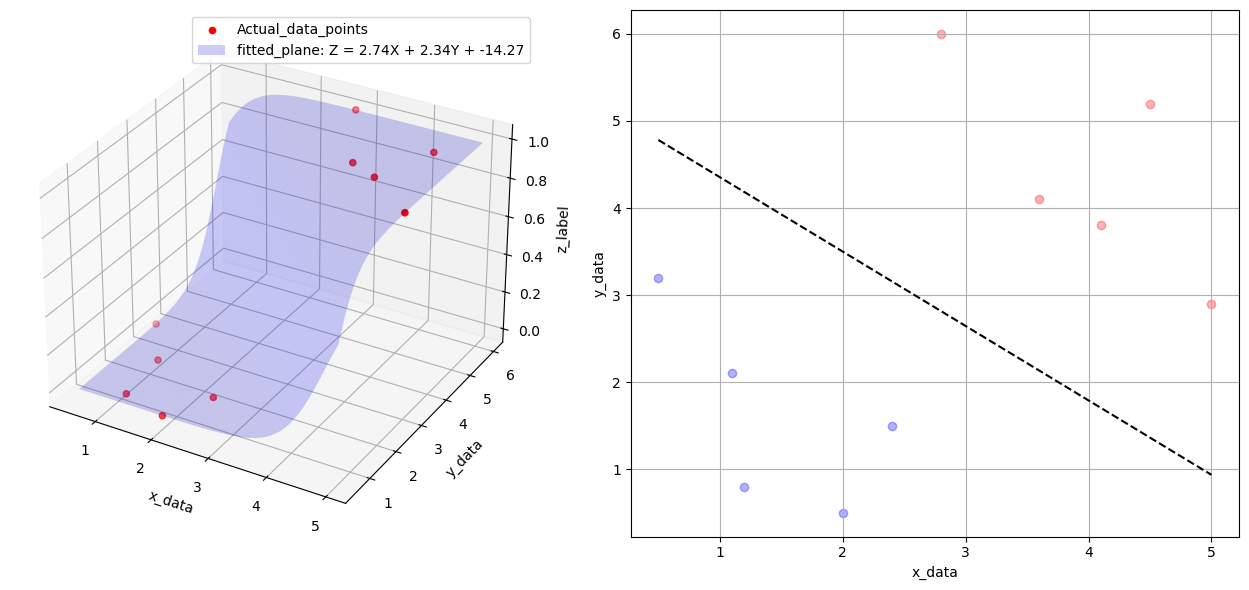

In [11]:
x = np.array([1.2,2.4,0.5,1.1,2.0,4.5,3.6,5.0,2.8,4.1])
y = np.array([0.8,1.5,3.2,2.1,0.5,5.2,4.1,2.9,6.0,3.8])
z = np.array([0,0,0,0,0,1,1,1,1,1])
m = len(x)
def get_constants(x,y,z):
    a,b,c = 0.0,0.0,0.0
    itr_max = 50000
    lr = 0.05
    for i in range(itr_max):
        p = 1/(1+np.exp(-(a*x+ b*y + c)))
        da = (1/m)*(np.dot((p-z), x))
        db = (1/m)*(np.dot((p-z), y))
        dc = (1/m)*(np.sum(p-z))
        a = a - lr*da
        b = b - lr*db
        c = c - lr*dc
    return a,b,c
def predict(a,b,c,x,y):
    x,y = np.array(x), np.array(y)
    prob = 1/(1+np.exp(-(a*x + b*y + c)))
    return (prob >=0.5).astype(int)
def prob(a,b,c,x,y):
    x,y = np.array(x), np.array(y)
    proba = [float(round(ele,6)) for ele in 1/(1+np.exp(-(a*x + b*y + c)))]
    return proba
a,b,c = get_constants(x,y,z)
print(f'weight(x): {a:.4f} weight(y): {b:.4f} bias: {c:.4f}')
print(f'x_data:           ',x)
print(f'y_data:           ',y)
print(f'Original_labels:  ',z)
print(f'probablities:     ',prob(a,b,c,x,y))
print(f'Model_predictions:',predict(a,b,c,x,y))
y_pred = predict(a,b,c,x,y)
plt.figure(figsize = (13,6))
ax = plt.subplot(1, 2, 1, projection="3d")
ax.scatter(x,y,z, color = 'red', label = 'Actual_data_points')
x_surf = np.linspace(x.min(), x.max(), 200)
y_surf = np.linspace(y.min(), y.max(), 200)
X, Y = np.meshgrid(x_surf, y_surf)
eq_smooth = a*X + b*Y + c
p_smooth = p = 1/(1+np.exp(-eq_smooth))
ax.plot_surface(X,Y,p_smooth, color = 'blue',  alpha= 0.2, label = f'fitted_plane: Z = {a:.2f}X + {b:.2f}Y + {c:.2f}')
ax.set_xlabel('x_data')
ax.set_ylabel('y_data')
ax.set_zlabel('z_label')
plt.legend()
plt.subplot(1,2,2)
plt.grid()
for j in range(len(x)):
    if z[j] == 0: plt.scatter(x[j], y[j], color='blue', alpha=0.3)
    else: plt.scatter(x[j], y[j], color='red', alpha=0.3)
plt.plot(x_surf, -(c+b*x_surf)/a, color='black', linestyle='--')
plt.xlabel('x_data')
plt.ylabel('y_data')
plt.tight_layout()
plt.show()